In [1]:

#GEREKLİ KÜTÜPHANELER

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import StratifiedKFold, ParameterSampler, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12



Gerekli tüm kütüphaneleri import ediyorum

In [2]:
#SEED AYARLARI VE CIHAZ

def set_seed(seed=42):
    """Tüm rastgelelik kaynaklarını sabitle"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🎯 Kullanılan cihaz: {device}")
print(f"🎯 CUDA kullanılabilir: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎯 GPU: {torch.cuda.get_device_name(0)}")



🎯 Kullanılan cihaz: cuda
🎯 CUDA kullanılabilir: True
🎯 GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Rastgeleliği sabitledim ve GPU'yu hazırladım.

In [3]:
#KONFİGÜRASYON

class Config:
    """Tüm yapılandırma ayarları"""
    # Dataset
    DATASET_DIR = r"C:\Users\Kardelen\Desktop\dlp\garbage-dataset"
    
    IMG_SIZE = 224
    BACKBONE = "densenet121"
    
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    N_SPLITS = 5
    RANDOM_STATE = 42
    
    RANDOM_SEARCH_ITER = 5 #5
    RANDOM_SEARCH_PARAMS = {
        'lr': [1e-4, 5e-4, 1e-3, 1e-5],
        'weight_decay': [1e-4, 1e-5, 1e-3],
        'dropout': [0.3, 0.5, 0.7]
    }
    
    PHASE1_EPOCHS = 5  # Head training
    PHASE2_EPOCHS = 20  # Fine-tuning
    EARLY_STOPPING_PATIENCE = 5
    
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

config = Config()



Proje ayarlarını bir sınıfta topladım. Görüntülerin boyutu, kullanılacak model, batch boyutu gibi temel değerleri belirledim. Ayrıca hiperparametre arama için aranacak değerleri ve görüntü normalizasyon ayarlarını ekledim.


📁 DATASET YÜKLENİYOR
✅ 10 sınıf bulundu:
    0: battery
    1: biological
    2: cardboard
    3: clothes
    4: glass
    5: metal
    6: paper
    7: plastic
    8: shoes
    9: trash


📸 Görüntüler okunuyor: 100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 38.91it/s]



📊 Dataset istatistikleri:
   Toplam görüntü: 19762
   Sınıf sayısı: 10


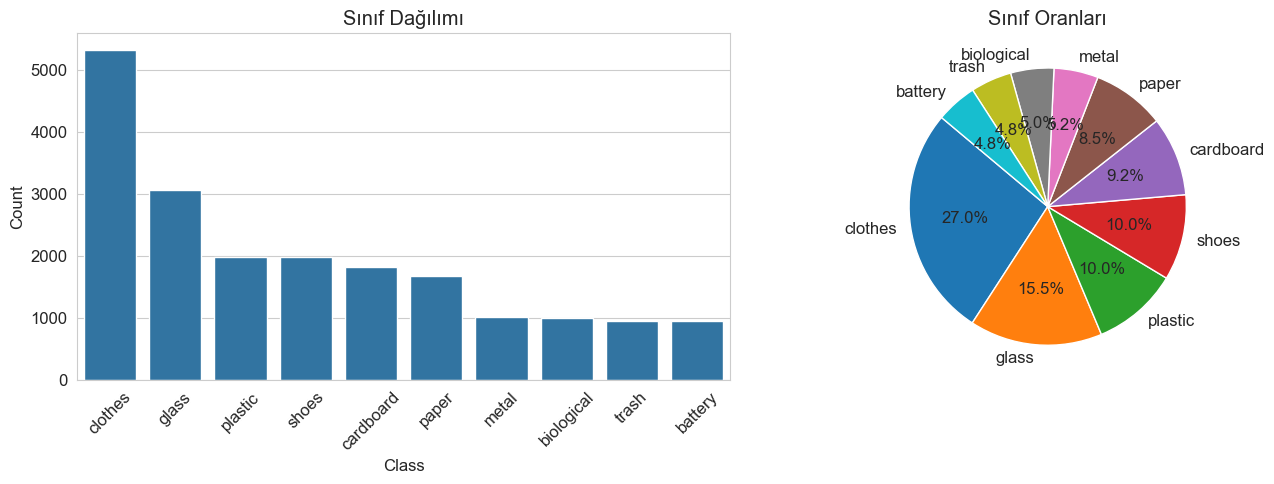

In [4]:
#DATASET YÜKLEME VE ANALİZ

print("\n" + "="*60)
print("📁 DATASET YÜKLENİYOR")
print("="*60)

class_names = sorted([
    d for d in os.listdir(config.DATASET_DIR)
    if os.path.isdir(os.path.join(config.DATASET_DIR, d))
])
num_classes = len(class_names)

print(f"✅ {num_classes} sınıf bulundu:")
for i, cls in enumerate(class_names):
    print(f"   {i:2d}: {cls}")

class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

data = []
for cls in tqdm(class_names, desc="📸 Görüntüler okunuyor"):
    cls_path = os.path.join(config.DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    for img in images:
        data.append({
            "image_path": os.path.join(cls_path, img),
            "label": class_to_idx[cls],
            "class_name": cls
        })

df = pd.DataFrame(data)
print(f"\n📊 Dataset istatistikleri:")
print(f"   Toplam görüntü: {len(df)}")
print(f"   Sınıf sayısı: {num_classes}")

class_distribution = df["class_name"].value_counts().reset_index()
class_distribution.columns = ["Class", "Count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="Class", y="Count", data=class_distribution, ax=axes[0])
axes[0].set_title("Sınıf Dağılımı")
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(class_distribution["Count"], labels=class_distribution["Class"], 
           autopct="%1.1f%%", startangle=140)
axes[1].set_title("Sınıf Oranları")
plt.tight_layout()
plt.show()



Dataset'i yükledim ve analiz ettim. Klasörlerden sınıfları okuyup görüntü yollarını bir DataFrame'de topladım. Her sınıftaki görüntü sayısını hesaplayıp görselleştirdim. Çubuk grafik ve pasta grafik ile dağılımı inceledim.

In [5]:
#DATA TRANSFORMS

print("\n" + "="*60)
print("🔄 DATA AUGMENTATION AYARLARI")
print("="*60)

train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.IMAGENET_MEAN, std=config.IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.IMAGENET_MEAN, std=config.IMAGENET_STD)
])

print("✅ Transformations tanımlandı")
print(f"   Train transforms: {len(train_transforms.transforms)} augmentation")
print(f"   Val/Test transforms: Temiz")




🔄 DATA AUGMENTATION AYARLARI
✅ Transformations tanımlandı
   Train transforms: 7 augmentation
   Val/Test transforms: Temiz


Veri artırma ve ön işleme ayarlarını yaptım. Eğitim için yatay çevirme, döndürme, renk ayarı ve kırpma gibi çeşitlendirmeler ekledim. 

In [6]:
#CUSTOM DATASET SINIFI

class TrashDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]
        class_name = row["class_name"]
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return {
            "image": image,
            "label": label,
            "class_name": class_name,
            "image_path": image_path
        }


Özel bir Dataset sınıfı oluşturdum. Bu sınıf, görüntüleri yükleyip transform işlemlerini uyguluyor.Her görüntüyü açıp RGB'ye çeviriyor ve belirlenen dönüşümleri uyguluyor. Görüntü, etiket, sınıf adı ve dosya yolu bilgilerini döndürüyor.


✂️  DATA SPLITTING
📊 Split istatistikleri:
   Train (final) : 12647 görüntü (64.0%)
   Validation    : 3162 görüntü (16.0%)
   Test          : 3953 görüntü (20.0%)


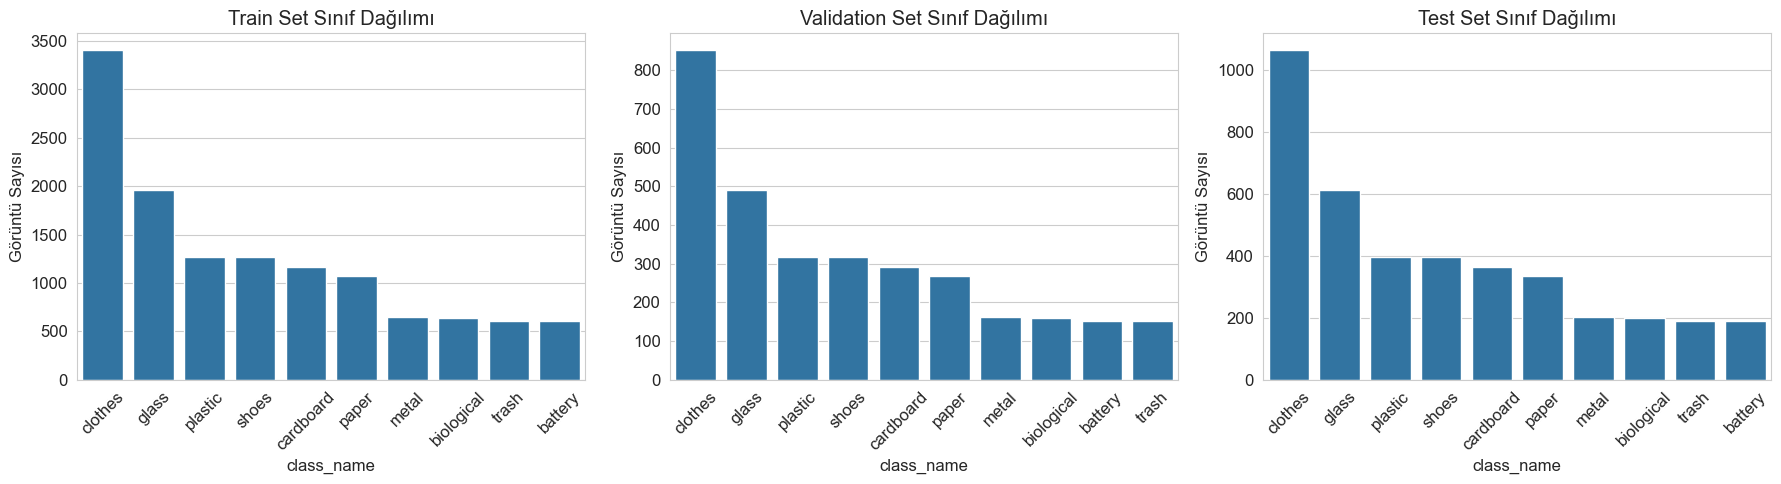


🔄 DATALOADERS OLUŞTURULUYOR
✅ DataLoaders oluşturuldu:
   Train batches : 396
   Val batches   : 99
   Test batches  : 124


In [7]:
#DATA SPLITTING

print("\n" + "="*60)
print("✂️  DATA SPLITTING")
print("="*60)

X = df["image_path"].values
y = df["label"].values

# Stratified K-Fold
skf = StratifiedKFold(n_splits=config.N_SPLITS, shuffle=True, random_state=config.RANDOM_STATE)
folds = list(skf.split(X, y))

# İlk fold'u kullan
train_idx, test_idx = folds[0]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    stratify=y_train,
    random_state=config.RANDOM_STATE
)

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

train_final_df = pd.DataFrame({
    "image_path": X_train_final,
    "label": y_train_final,
    "class_name": [idx_to_class[label] for label in y_train_final]
})

val_df = pd.DataFrame({
    "image_path": X_val,
    "label": y_val,
    "class_name": [idx_to_class[label] for label in y_val]
})

print(f"📊 Split istatistikleri:")
print(f"   Train (final) : {len(train_final_df)} görüntü ({len(train_final_df)/len(df)*100:.1f}%)")
print(f"   Validation    : {len(val_df)} görüntü ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test          : {len(test_df)} görüntü ({len(test_df)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data_df) in enumerate([
    ("Train", train_final_df),
    ("Validation", val_df),
    ("Test", test_df)
]):
    dist = data_df["class_name"].value_counts()
    sns.barplot(x=dist.index, y=dist.values, ax=axes[idx])
    axes[idx].set_title(f"{name} Set Sınıf Dağılımı")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylabel("Görüntü Sayısı")

plt.tight_layout()
plt.show()


#DATALOADERS

print("\n" + "="*60)
print("🔄 DATALOADERS OLUŞTURULUYOR")
print("="*60)

train_dataset = TrashDataset(train_final_df, transform=train_transforms)
val_dataset = TrashDataset(val_df, transform=val_test_transforms)
test_dataset = TrashDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory= False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ DataLoaders oluşturuldu:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")



Veriyi katmanlı bir şekilde böldüm. Önce 5 katlı çapraz doğrulama yapısı kurup ilk fold'u seçtim. Sonra eğitim setini %80 eğitim, %20 doğrulama olacak şekilde ayırdım. Her setin sınıf dağılımını kontrol ettim ve görselleştirdim. Son olarak, her set için DataLoader'lar oluşturdum. Böylece model eğitimi için veri hazır hale geldi.

In [8]:
#CLASS WEIGHTS

print("\n" + "="*60)
print("⚖️  CLASS WEIGHTS HESAPLANIYOR")
print("="*60)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_final_df["label"]),
    y=train_final_df["label"]
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("📊 Class weights:")
for idx, weight in enumerate(class_weights):
    print(f"   {idx_to_class[idx]:<15}: {weight:.4f}")




⚖️  CLASS WEIGHTS HESAPLANIYOR
📊 Class weights:
   battery        : 2.0939
   biological     : 1.9823
   cardboard      : 1.0828
   clothes        : 0.3710
   glass          : 0.6456
   metal          : 1.9368
   paper          : 1.1765
   plastic        : 0.9966
   shoes          : 0.9990
   trash          : 2.0870


Sınıf dengesizliğini gidermek için class weights hesapladım. Her sınıfa, görüntü sayısına ters orantılı ağırlıklar atadım. Bu ağırlıkları CrossEntropyLoss fonksiyonuna verdim. Böylece az örnek olan sınıflara daha fazla önem verilerek modelin daha dengeli öğrenmesini sağladım.

In [9]:
#MODEL OLUŞTURMA FONKSİYONU

def get_densenet121(num_classes, dropout_rate=0.5, pretrained=True):
    """DenseNet121 modelini oluştur"""
    if pretrained:
        model = models.densenet121(weights="DEFAULT")
    else:
        model = models.densenet121(weights=None)
    
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes)
    )
    
    return model



DenseNet121 modelini projemin ihtiyaçlarına göre özelleştiriyorum. Modelin çıktı katmanını kendi sınıf sayıma uygun şekilde değiştiriyor, araya 512 nöronlu bir katman ve dropout ekliyorum. İstersem önceden eğitilmiş ağırlıklarla da başlatabiliyorum.


In [10]:
#YARDIMCI FONKSİYONLAR

def calculate_accuracy(outputs, labels):
    """Accuracy hesapla"""
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)

class EarlyStopping:
    """Early stopping sınıfı"""
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Bir epoch eğitim"""
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for batch in tqdm(loader, desc="Eğitim", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def validate_one_epoch(model, loader, criterion, device):
    """Validation"""
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def unfreeze_gradually(model, current_phase, total_phases=3):
    """
    KADEMELİ TRANSFER LEARNING
    current_phase: 0=phase1, 1=phase2a, 2=phase2b, 3=phase2c
    """
    print(f"\n🔓 Transfer Learning Phase {current_phase}")
    
    if current_phase == 0:
        # PHASE 1: Sadece classifier
        print("   Sadece classifier eğitiliyor")
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.classifier.parameters():
            param.requires_grad = True
    
    elif current_phase == 1:
        # PHASE 2A: Son 1 block
        print("   Son denseblock4 ve norm5 açılıyor")
        for name, param in model.features.named_parameters():
            if 'denseblock4' in name or 'norm5' in name:
                param.requires_grad = True
    
    elif current_phase == 2:
        # PHASE 2B: Son 2 block
        print("   denseblock3, transition3 ve sonrası açılıyor")
        for name, param in model.features.named_parameters():
            if any(block in name for block in ['denseblock3', 'transition3', 'denseblock4', 'norm5']):
                param.requires_grad = True
    
    elif current_phase == 3:
        # PHASE 2C: Son 3 block
        print("   denseblock2, transition2 ve sonrası açılıyor")
        for name, param in model.features.named_parameters():
            if any(block in name for block in ['denseblock2', 'transition2', 'denseblock3', 'transition3', 'denseblock4', 'norm5']):
                param.requires_grad = True
    
    # Eğitilebilir parametre sayısını hesapla
    trainable = sum(p.requires_grad for p in model.parameters())
    total = sum(1 for _ in model.parameters())
    print(f"   Eğitilebilir parametreler: {trainable}/{total} ({trainable/total*100:.1f}%)")

Bu fonksiyonlarım model eğitimini yönetmemi sağlıyor. Doğruluğu hesaplıyorum, gereksiz eğitimi erken durdurma ile engelliyorum. Eğitim ve doğrulama adımlarını ayrı ayrı işliyorum. En önemlisi, katmanları aşamalı çözerek transfer öğrenimini kademeli uyguluyorum. Bu sayede model hem önceki bilgisini koruyor hem de yeni görevime verimli şekilde uyum sağlıyor.

In [11]:
#RANDOM SEARCH

def random_search_optimization(param_grid, n_iter=5):
    """
    OPTİMİZE EDİLMİŞ RANDOM SEARCH
    - Model, optimizer ve scheduler state'lerini kaydeder
    - Gerçek entegrasyon sağlar
    """
    print("\n" + "="*60)
    print("🔍 RANDOM SEARCH BAŞLIYOR")
    print("="*60)
    
    param_list = list(ParameterSampler(
        param_grid, n_iter=n_iter, random_state=config.RANDOM_STATE
    ))
    
    results = []
    
    for i, params in enumerate(param_list):
        print(f"\n🎯 DENEME {i+1}/{n_iter}")
        print(f"   LR: {params['lr']:.0e}, WD: {params['weight_decay']:.0e}, Dropout: {params['dropout']}")
        
        #MODEL OLUŞTUR
        model_rs = get_densenet121(
            num_classes=num_classes,
            dropout_rate=params['dropout'],
            pretrained=True
        ).to(device)
        
        #BACKBONE DONDUR (HEAD TRAINING)
        for param in model_rs.features.parameters():
            param.requires_grad = False
        
        #OPTIMIZER
        optimizer_rs = optim.AdamW(
            filter(lambda p: p.requires_grad, model_rs.parameters()),
            lr=params['lr'],
            weight_decay=params['weight_decay']
        )
        
        scheduler_rs = optim.lr_scheduler.CosineAnnealingLR(
            optimizer_rs, T_max=5, eta_min=1e-5
        )
        
        #HEAD TRAINING
        early_stopping = EarlyStopping(patience=2)
        best_val_loss = np.inf
        best_val_acc = 0
        
        print("Head training ")
        
        for epoch in range(5):
            train_loss, train_acc = train_one_epoch(
                model_rs, train_loader, optimizer_rs, criterion, device
            )
            
            val_loss, val_acc = validate_one_epoch(
                model_rs, val_loader, criterion, device
            )
            
            scheduler_rs.step()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_model_state = model_rs.state_dict().copy()
                best_optimizer_state = optimizer_rs.state_dict().copy()
                best_scheduler_state = scheduler_rs.state_dict().copy()
            
            early_stopping(val_loss)
            if early_stopping.early_stop:
                break
        
        #SONUÇLARI KAYDET
        results.append({
            'params': params,
            'best_val_loss': best_val_loss,
            'best_val_acc': best_val_acc,
            'model_state': best_model_state,
            'optimizer_state': best_optimizer_state,
            'scheduler_state': best_scheduler_state
        })
        
        print(f"   ✓ Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")
    
    # EN İYİ PARAMETRELERİ BUL
    best_result = min(results, key=lambda x: x['best_val_loss'])
   
    print("\n" + "="*60)
    print("📊 RANDOM SEARCH SONUÇLARI")
    print("="*60)
    
    results_df = pd.DataFrame([{
        'Trial': i+1,
        'LR': f"{r['params']['lr']:.0e}",
        'WD': f"{r['params']['weight_decay']:.0e}",
        'Dropout': r['params']['dropout'],
        'Val Loss': f"{r['best_val_loss']:.4f}",
        'Val Acc': f"{r['best_val_acc']:.4f}"
    } for i, r in enumerate(results)])
    
    print(results_df.to_string(index=False))
    
    print(f"\n🏆 EN İYİ PARAMETRELER:")
    print(f"   LR: {best_result['params']['lr']}")
    print(f"   Weight Decay: {best_result['params']['weight_decay']}")
    print(f"   Dropout: {best_result['params']['dropout']}")
    print(f"   Validation Loss: {best_result['best_val_loss']:.4f}")
    print(f"   Validation Accuracy: {best_result['best_val_acc']:.4f}")
    
    return best_result, results


Random search yaparak en iyi hiperparametreleri buldum. Her denemede dropout, learning rate ve weight decay değerlerini değiştirip modeli eğittim. En düşük validation loss'a sahip parametre setini seçtim.

In [12]:

#RANDOM SEARCH ÇALIŞTIR

best_result, all_results = random_search_optimization(
    param_grid=config.RANDOM_SEARCH_PARAMS,
    n_iter=config.RANDOM_SEARCH_ITER
)

print("\n" + "="*60)
print("🚀 RANDOM SEARCH PARAMETRELERİ İLE MODEL OLUŞTURULUYOR")
print("="*60)

#Modeli oluştur
model = get_densenet121(
    num_classes=num_classes,
    dropout_rate=best_result['params']['dropout'],
    pretrained=True  # ImageNet weights ile başla
).to(device)

print("✅ Model ImageNet weights ile oluşturuldu")

#Backbone'u dondur
for param in model.features.parameters():
    param.requires_grad = False

print("🔒 Backbone donduruldu")

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=best_result['params']['lr'],
    weight_decay=best_result['params']['weight_decay']
)

print("✅ Optimizer random search parametreleriyle oluşturuldu")

#Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.PHASE1_EPOCHS,
    eta_min=1e-5
)

print(f"\n📊 KULLANILAN PARAMETRELER (Random Search'ten):")
print(f"   Learning Rate: {best_result['params']['lr']:.0e}")
print(f"   Weight Decay: {best_result['params']['weight_decay']:.0e}")
print(f"   Dropout: {best_result['params']['dropout']}")
print(f"   Random Search Validation Loss: {best_result['best_val_loss']:.4f}")



🔍 RANDOM SEARCH BAŞLIYOR

🎯 DENEME 1/5
   LR: 1e-05, WD: 1e-03, Dropout: 0.7
Head training 


   ✓ Val Loss: 1.2050, Val Acc: 0.8319

🎯 DENEME 2/5
   LR: 1e-04, WD: 1e-05, Dropout: 0.5
Head training 


   ✓ Val Loss: 0.3950, Val Acc: 0.9025

🎯 DENEME 3/5
   LR: 1e-04, WD: 1e-03, Dropout: 0.7
Head training 


   ✓ Val Loss: 0.4326, Val Acc: 0.8977

🎯 DENEME 4/5
   LR: 1e-03, WD: 1e-04, Dropout: 0.7
Head training 


   ✓ Val Loss: 0.3082, Val Acc: 0.9175

🎯 DENEME 5/5
   LR: 5e-04, WD: 1e-05, Dropout: 0.5
Head training 


   ✓ Val Loss: 0.3011, Val Acc: 0.9225

📊 RANDOM SEARCH SONUÇLARI
 Trial    LR    WD  Dropout Val Loss Val Acc
     1 1e-05 1e-03      0.7   1.2050  0.8319
     2 1e-04 1e-05      0.5   0.3950  0.9025
     3 1e-04 1e-03      0.7   0.4326  0.8977
     4 1e-03 1e-04      0.7   0.3082  0.9175
     5 5e-04 1e-05      0.5   0.3011  0.9225

🏆 EN İYİ PARAMETRELER:
   LR: 0.0005
   Weight Decay: 1e-05
   Dropout: 0.5
   Validation Loss: 0.3011
   Validation Accuracy: 0.9225

🚀 RANDOM SEARCH PARAMETRELERİ İLE MODEL OLUŞTURULUYOR
✅ Model ImageNet weights ile oluşturuldu
🔒 Backbone donduruldu
✅ Optimizer random search parametreleriyle oluşturuldu

📊 KULLANILAN PARAMETRELER (Random Search'ten):
   Learning Rate: 5e-04
   Weight Decay: 1e-05
   Dropout: 0.5
   Random Search Validation Loss: 0.3011


Random search ile bulduğum en iyi hiperparametreleri kullanarak modeli yeniden başlattım. Önceden eğitilmiş DenseNet121 kullandım ve backbone'u dondurdum. Optimizer'ı bulunan learning rate ve weight decay değerleriyle ayarladım. Learning rate scheduler ekledim. Böylece model en optimal ayarlarla eğitime hazır hale geldi.

In [13]:

#PHASE 1: HEAD TRAINING
print("\n" + "="*60)
print("🟢 PHASE 1: HEAD TRAINING (Backbone Frozen)")
print("="*60)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("🔒 Backbone donduruldu, sadece classifier eğitilecek")

train_losses_phase1 = []
val_losses_phase1 = []
train_accs_phase1 = []
val_accs_phase1 = []

early_stopping = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_val_loss = np.inf

#PHASE 1 EĞİTİM
for epoch in range(config.PHASE1_EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{config.PHASE1_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler.step()
    
    train_losses_phase1.append(train_loss)
    val_losses_phase1.append(val_loss)
    train_accs_phase1.append(train_acc)
    val_accs_phase1.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"   LR        : {current_lr:.2e}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, "best_model_phase1.pth")
        print("   💾 Best model kaydedildi (Phase 1)")
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("   ⏹️  Early stopping triggered")
        break




🟢 PHASE 1: HEAD TRAINING (Backbone Frozen)
🔒 Backbone donduruldu, sadece classifier eğitilecek

📅 Epoch 1/5


   Train Loss: 0.8776 | Train Acc: 0.7494
   Val Loss  : 0.4543 | Val Acc  : 0.8731
   LR        : 4.53e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 2/5


   Train Loss: 0.5331 | Train Acc: 0.8411
   Val Loss  : 0.3665 | Val Acc  : 0.9037
   LR        : 3.31e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 3/5


   Train Loss: 0.4594 | Train Acc: 0.8599
   Val Loss  : 0.3358 | Val Acc  : 0.9077
   LR        : 1.79e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 4/5


   Train Loss: 0.4058 | Train Acc: 0.8748
   Val Loss  : 0.3230 | Val Acc  : 0.9157
   LR        : 5.68e-05
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 5/5


   Train Loss: 0.3797 | Train Acc: 0.8846
   Val Loss  : 0.3064 | Val Acc  : 0.9203
   LR        : 1.00e-05
   💾 Best model kaydedildi (Phase 1)


Phase 1'de sadece modelin classifier kısmını eğittim. Backbone tamamen donduruldu. Her epoch'ta train/validation kayıplarını ve doğruluklarını takip ettim. En iyi modeli kaydettim ve early stopping ile gereksiz eğitimi önledim. Böylece model önce yeni sınıflara adapte oldu.

In [14]:
#PHASE 2: KADEMELİ FINE-TUNING

print("\n" + "="*60)
print("🔵 PHASE 2: KADEMELİ FINE-TUNING (4 Aşamalı)")
print("="*60)

# Phase 1'den en iyi modeli yükle
checkpoint = torch.load("best_model_phase1.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
print("✅ Phase 1 best model yüklendi")

# PHASE 2 AYARLARI
phase2_epochs_per_phase = 5  # Her aşama için epoch sayısı
total_phase2_epochs = phase2_epochs_per_phase * 3  # Toplam 15 epoch

train_losses_phase2 = []
val_losses_phase2 = []
train_accs_phase2 = []
val_accs_phase2 = []

early_stopping = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_val_loss_ft = np.inf

# KADEMELİ FINE-TUNING DÖNGÜSÜ
current_phase = 0  # Phase 1'den sonra başlıyoruz

for phase in range(3):  # 3 aşama: 2A, 2B, 2C
    print(f"\n{'='*50}")
    print(f"🎯 FINE-TUNING AŞAMA {phase+1}/3")
    print(f"{'='*50}")
    
    # Bu aşama için katmanları aç
    unfreeze_gradually(model, phase + 1)
    
    # Her aşama için yeni optimizer (daha düşük LR)
    lr_multiplier = 0.1 ** (phase + 1)  # 0.1, 0.01, 0.001
    optimizer_ft = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=best_result['params']['lr'] * lr_multiplier,
        weight_decay=best_result['params']['weight_decay']
    )
    
    scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ft,
        T_max=phase2_epochs_per_phase,
        eta_min=1e-6
    )
    
    # Bu aşama için eğitim
    for epoch in range(phase2_epochs_per_phase):
        epoch_num = phase * phase2_epochs_per_phase + epoch + 1
        print(f"\n📅 Epoch {epoch_num}/{total_phase2_epochs} (Aşama {phase+1}.{epoch+1})")
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer_ft, criterion, device
        )
        
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, device
        )
        
        scheduler_ft.step()
        
        train_losses_phase2.append(train_loss)
        val_losses_phase2.append(val_loss)
        train_accs_phase2.append(train_acc)
        val_accs_phase2.append(val_acc)
        
        current_lr = optimizer_ft.param_groups[0]['lr']
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"   Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
        print(f"   LR        : {current_lr:.2e}")
        
        if val_loss < best_val_loss_ft:
            best_val_loss_ft = val_loss
            torch.save({
                'epoch': epoch_num,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer_ft.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'phase': phase + 1
            }, "best_model_final.pth")
            print("   💾 Best model kaydedildi")
        
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("   ⏹️  Early stopping triggered")
            break
    
    if early_stopping.early_stop:
        break

print(f"\n✅ Kademeli fine-tuning tamamlandı!")
print(f"   Toplam Phase 2 epoch: {len(train_losses_phase2)}")
print(f"   En iyi validation loss: {best_val_loss_ft:.4f}")



🔵 PHASE 2: KADEMELİ FINE-TUNING (4 Aşamalı)
✅ Phase 1 best model yüklendi

🎯 FINE-TUNING AŞAMA 1/3

🔓 Transfer Learning Phase 1
   Son denseblock4 ve norm5 açılıyor
   Eğitilebilir parametreler: 102/366 (27.9%)

📅 Epoch 1/15 (Aşama 1.1)


   Train Loss: 0.3484 | Train Acc: 0.8940
   Val Loss  : 0.2455 | Val Acc  : 0.9389
   LR        : 4.53e-05
   💾 Best model kaydedildi

📅 Epoch 2/15 (Aşama 1.2)


   Train Loss: 0.2728 | Train Acc: 0.9150
   Val Loss  : 0.2107 | Val Acc  : 0.9444
   LR        : 3.31e-05
   💾 Best model kaydedildi

📅 Epoch 3/15 (Aşama 1.3)


   Train Loss: 0.2321 | Train Acc: 0.9255
   Val Loss  : 0.1964 | Val Acc  : 0.9485
   LR        : 1.79e-05
   💾 Best model kaydedildi

📅 Epoch 4/15 (Aşama 1.4)


   Train Loss: 0.1974 | Train Acc: 0.9366
   Val Loss  : 0.1906 | Val Acc  : 0.9487
   LR        : 5.68e-06
   💾 Best model kaydedildi

📅 Epoch 5/15 (Aşama 1.5)


...

   Train Loss: 0.1438 | Train Acc: 0.9544
   Val Loss  : 0.1795 | Val Acc  : 0.9516
   LR        : 5.48e-07

📅 Epoch 12/15 (Aşama 3.2)


   Train Loss: 0.1405 | Train Acc: 0.9543
   Val Loss  : 0.1767 | Val Acc  : 0.9520
   LR        : 6.73e-07

📅 Epoch 13/15 (Aşama 3.3)


   Train Loss: 0.1397 | Train Acc: 0.9540
   Val Loss  : 0.1706 | Val Acc  : 0.9533
   LR        : 8.27e-07
   💾 Best model kaydedildi

📅 Epoch 14/15 (Aşama 3.4)


   Train Loss: 0.1446 | Train Acc: 0.9505
   Val Loss  : 0.1757 | Val Acc  : 0.9504
   LR        : 9.52e-07

📅 Epoch 15/15 (Aşama 3.5)


   Train Loss: 0.1339 | Train Acc: 0.9579
   Val Loss  : 0.1731 | Val Acc  : 0.9520
   LR        : 1.00e-06

✅ Kademeli fine-tuning tamamlandı!
   Toplam Phase 2 epoch: 15
   En iyi validation loss: 0.1706


Bu kodda, modelimi kademeli fine-tuning ile en iyi şekilde uyarlıyorum. Önce Phase 1'de eğittiğim en iyi modeli yüklüyorum. Daha sonra modeli 3 aşamada eğitiyorum: önce sadece son katmanları, sonra geriye doğru giderek daha fazla katmanı eğitime açıyorum. Her aşamada öğrenme oranını düşürerek daha hassas ayarlamalar yapıyorum. Her epoch'ta kayıp ve doğruluk değerlerini takip ediyor, en iyi modeli kaydediyor ve gereksiz eğitimi erken durdurma ile önlüyorum.

In [15]:

#TEST EVALUATION

print("\n" + "="*60)
print("🧪 TEST SET EVALUATION")
print("="*60)

# Final modeli yükle
checkpoint = torch.load("best_model_final.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test değerlendirme"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)




🧪 TEST SET EVALUATION


Test değerlendirme: 100%|████████████████████████████████████████████████████████████| 124/124 [01:35<00:00,  1.30it/s]


Final modeli test setinde değerlendirdim. Modelden tahminler ve olasılık değerleri topladım. Tüm test görüntüleri için gerçek etiketler, tahminler ve sınıf olasılıklarını kaydettim. Böylece detaylı metrik analizleri yapabileceğim.

In [16]:

#METRİKLERİ HESAPLA

print("\n" + "="*60)
print("📈 PERFORMANS METRİKLERİ")
print("="*60)

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
kappa = cohen_kappa_score(all_labels, all_preds)

roc_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="macro"
)

pr_auc_scores = []
for class_idx in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == class_idx).astype(int),
        all_probs[:, class_idx]
    )
    pr_auc_scores.append(auc(recall, precision))
macro_pr_auc = np.mean(pr_auc_scores)

try:
    from sklearn.metrics import top_k_accuracy_score
    top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5)
except:
    top5_acc = None

results_summary = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1", 
        "Cohen's Kappa",
        "ROC AUC (Macro)",
        "PR AUC (Macro)",
        "Top-5 Accuracy"
    ],
    "Value": [
        f"{accuracy:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_f1:.4f}",
        f"{kappa:.4f}",
        f"{roc_auc:.4f}",
        f"{macro_pr_auc:.4f}",
        f"{top5_acc:.4f}" if top5_acc else "N/A"
    ]
}

results_df = pd.DataFrame(results_summary)
print("\n📊 GENEL PERFORMANS:")
print(results_df.to_string(index=False))

print(f"\n🎯 KULLANILAN PARAMETRELER:")
print(f"   Learning Rate: {best_result['params']['lr']:.0e}")
print(f"   Weight Decay: {best_result['params']['weight_decay']:.0e}")
print(f"   Dropout: {best_result['params']['dropout']}")




📈 PERFORMANS METRİKLERİ

📊 GENEL PERFORMANS:
         Metric  Value
       Accuracy 0.9598
       Macro F1 0.9522
    Weighted F1 0.9600
  Cohen's Kappa 0.9532
ROC AUC (Macro) 0.9984
 PR AUC (Macro) 0.9858
 Top-5 Accuracy 0.9995

🎯 KULLANILAN PARAMETRELER:
   Learning Rate: 5e-04
   Weight Decay: 1e-05
   Dropout: 0.5


Test seti üzerinde çeşitli performans metrikleri hesapladım.

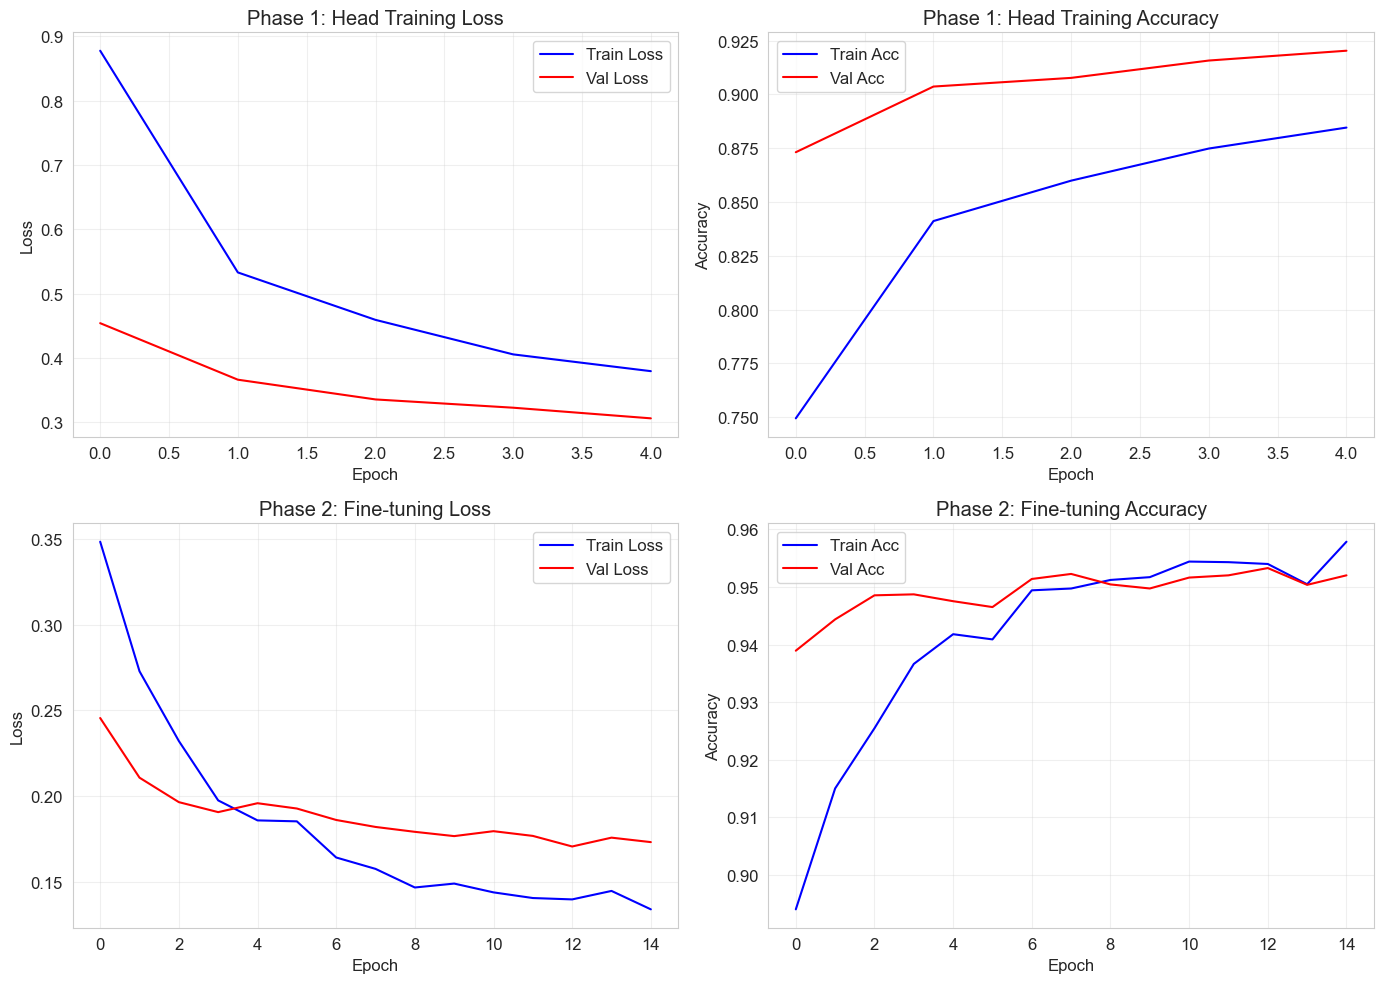

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1 Loss
axes[0, 0].plot(train_losses_phase1, 'b-', label='Train Loss')
axes[0, 0].plot(val_losses_phase1, 'r-', label='Val Loss')
axes[0, 0].set_title('Phase 1: Head Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 1 Accuracy
axes[0, 1].plot(train_accs_phase1, 'b-', label='Train Acc')
axes[0, 1].plot(val_accs_phase1, 'r-', label='Val Acc')
axes[0, 1].set_title('Phase 1: Head Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase 2 Loss
axes[1, 0].plot(train_losses_phase2, 'b-', label='Train Loss')
axes[1, 0].plot(val_losses_phase2, 'r-', label='Val Loss')
axes[1, 0].set_title('Phase 2: Fine-tuning Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase 2 Accuracy
axes[1, 1].plot(train_accs_phase2, 'b-', label='Train Acc')
axes[1, 1].plot(val_accs_phase2, 'r-', label='Val Acc')
axes[1, 1].set_title('Phase 2: Fine-tuning Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Eğitim sürecinin grafiklerini oluşturdum.


📈 DETAYLI PERFORMANS METRİKLERİ

📊 Ana Performans Metrikleri:


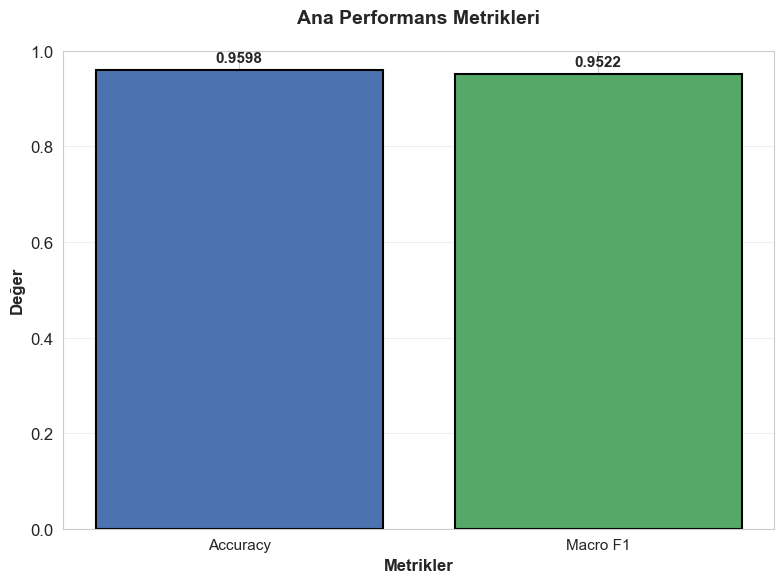

   Accuracy: 0.9598
   Macro F1: 0.9522


In [18]:

print("\n" + "="*60)
print("📈 DETAYLI PERFORMANS METRİKLERİ")
print("="*60)

#Ana Performans Metrikleri Görseli
print("\n📊 Ana Performans Metrikleri:")

main_metrics = {
    "Metric": ["Accuracy", "Macro F1"],
    "Value": [accuracy, macro_f1]
}

fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(len(main_metrics["Metric"]))
values = [accuracy, macro_f1]
colors = ["#4C72B0", "#55A868"]

bars = ax.bar(x_pos, values, color=colors, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Metrikler", fontsize=12, fontweight="bold")
ax.set_ylabel("Değer", fontsize=12, fontweight="bold")
ax.set_title("Ana Performans Metrikleri", fontsize=14, fontweight="bold", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(main_metrics["Metric"], fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"   Accuracy: {accuracy:.4f}")
print(f"   Macro F1: {macro_f1:.4f}")



 Accuracy ve Macro F1 değerlerini çubuk grafikte gösterdim. 


📊 Diğer Performans Metrikleri:


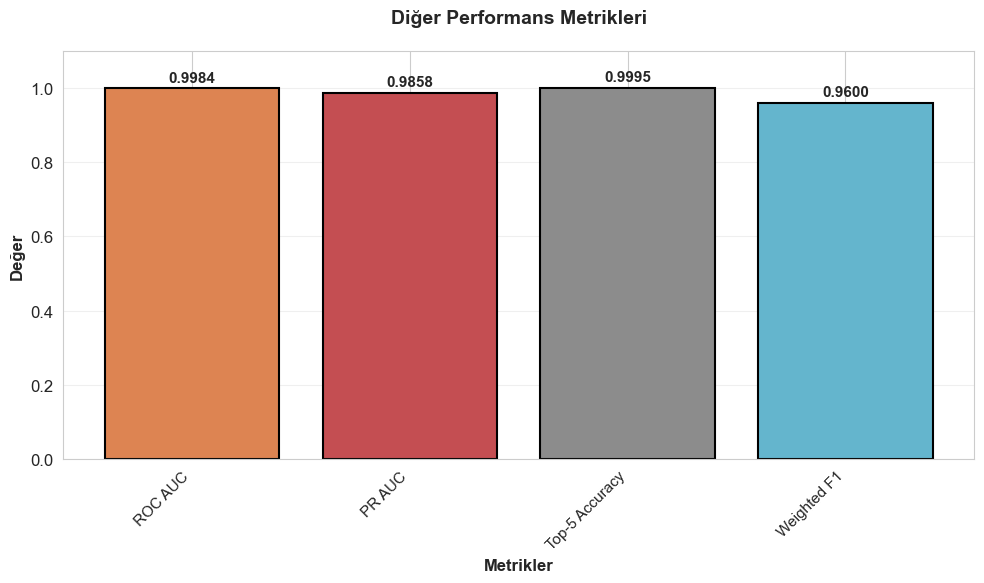

   ROC AUC: 0.9984
   PR AUC: 0.9858
   Top-5 Accuracy: 0.9995
   Weighted F1: 0.9600


In [19]:
#Diğer Performans Metrikleri

print("\n📊 Diğer Performans Metrikleri:")

other_metrics = {
    "Metric": ["ROC AUC", "PR AUC", "Top-5 Accuracy", "Weighted F1"],
    "Value": [roc_auc, macro_pr_auc, top5_acc if top5_acc else 0, weighted_f1]
}

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(other_metrics["Metric"]))
values = other_metrics["Value"]
colors = ["#DD8452", "#C44E52", "#8C8C8C", "#64B5CD"]

bars = ax.bar(x_pos, values, color=colors, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Metrikler", fontsize=12, fontweight="bold")
ax.set_ylabel("Değer", fontsize=12, fontweight="bold")
ax.set_title("Diğer Performans Metrikleri", fontsize=14, fontweight="bold", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(other_metrics["Metric"], fontsize=11, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, values):
    height = bar.get_height()
    if not np.isnan(value):
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"   ROC AUC: {roc_auc:.4f}")
print(f"   PR AUC: {macro_pr_auc:.4f}")
if top5_acc:
    print(f"   Top-5 Accuracy: {top5_acc:.4f}")
print(f"   Weighted F1: {weighted_f1:.4f}")



Diğer performans metriklerini görselleştirdim. ROC AUC, PR AUC, Top-5 Accuracy ve Weighted F1 değerlerini çubuk grafikte gösterdim.

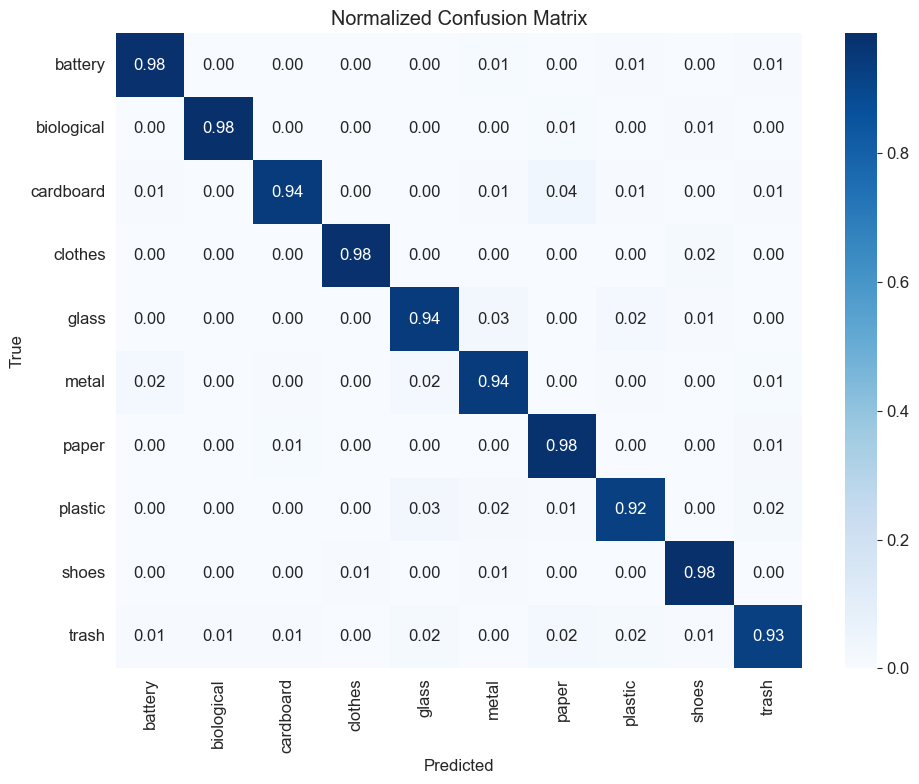

In [20]:

cm = confusion_matrix(all_labels, all_preds, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()



Normalize edilmiş karışıklık matrisi oluşturdum. Her sınıf için doğru ve yanlış tahmin oranlarını gösterdim

Sınıf Bazlı F1 Skorları:


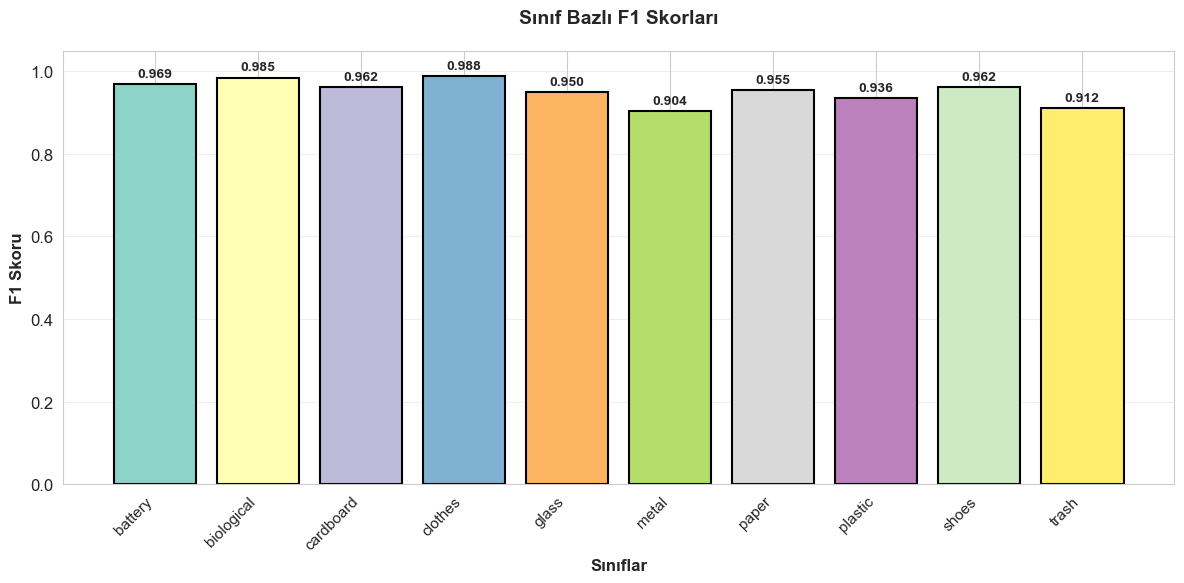

   battery        : 0.969
   biological     : 0.985
   cardboard      : 0.962
   clothes        : 0.988
   glass          : 0.950
   metal          : 0.904
   paper          : 0.955
   plastic        : 0.936
   shoes          : 0.962
   trash          : 0.912


In [22]:
# Sınıf Bazlı F1 Skorları

print("Sınıf Bazlı F1 Skorları:")

from sklearn.metrics import classification_report
class_report = classification_report(all_labels, all_preds, 
                                     target_names=class_names, 
                                     output_dict=True)

f1_scores = []
for class_name in class_names:
    if class_name in class_report:
        f1_scores.append(class_report[class_name]["f1-score"])

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(class_names))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))

bars = ax.bar(x_pos, f1_scores, color=colors, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Sınıflar", fontsize=12, fontweight="bold")
ax.set_ylabel("F1 Skoru", fontsize=12, fontweight="bold")
ax.set_title("Sınıf Bazlı F1 Skorları", fontsize=14, fontweight="bold", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

for class_name, score in zip(class_names, f1_scores):
    print(f"   {class_name:15}: {score:.3f}")

Her sınıf için F1 skorlarını görselleştirdim. 

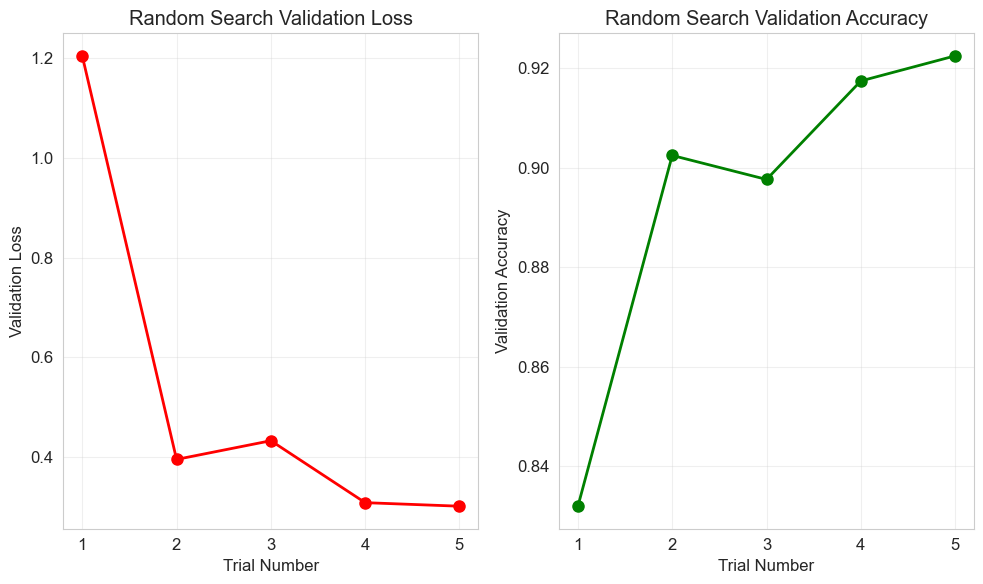

In [23]:
#Random Search Sonuçları
plt.figure(figsize=(10, 6))
trials = range(1, len(all_results) + 1)
val_losses = [r['best_val_loss'] for r in all_results]
val_accs = [r['best_val_acc'] for r in all_results]

plt.subplot(1, 2, 1)
plt.plot(trials, val_losses, 'o-', color='red', linewidth=2, markersize=8)
plt.xlabel('Trial Number')
plt.ylabel('Validation Loss')
plt.title('Random Search Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trials, val_accs, 'o-', color='green', linewidth=2, markersize=8)
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.title('Random Search Validation Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Random search denemelerinin sonuçlarını görselleştirdim. Her deneme için validation loss ve accuracy değerlerini grafikte gösterdim.


📊 ROC Eğrileri (One-vs-Rest):


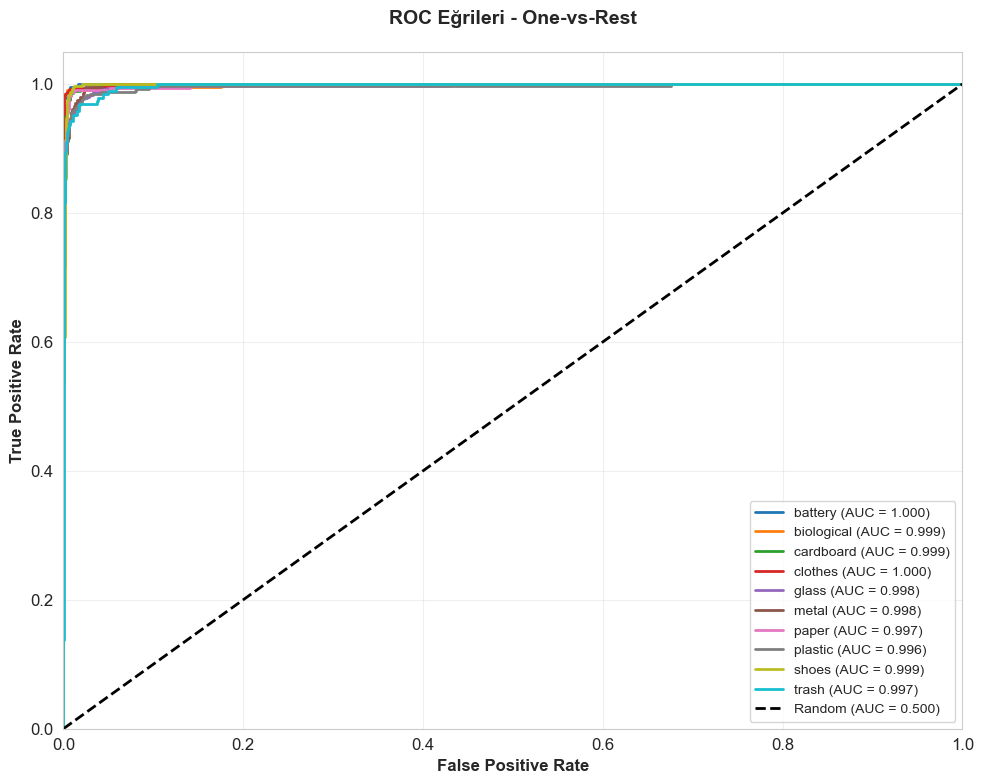

In [24]:

#ROC Eğrileri (One-vs-Rest)

print("\n📊 ROC Eğrileri (One-vs-Rest):")

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for class_idx in range(num_classes):
    # Binary label oluştur
    y_true_binary = (all_labels == class_idx).astype(int)
    y_score = all_probs[:, class_idx]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
             label=f'{class_names[class_idx]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")
plt.title('ROC Eğrileri - One-vs-Rest', fontsize=14, fontweight="bold", pad=20)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Modelin her sınıfı ne kadar iyi ayırt edebildiğini görselleştirmek için ROC eğrileri çizdim.


📊 Precision-Recall Eğrileri:
   battery        : Support = 189, PR AUC = 0.996
   biological     : Support = 200, PR AUC = 0.994
   cardboard      : Support = 365, PR AUC = 0.993
   clothes        : Support = 1065, PR AUC = 0.999
   glass          : Support = 612, PR AUC = 0.990
   metal          : Support = 204, PR AUC = 0.974
   paper          : Support = 336, PR AUC = 0.987
   plastic        : Support = 397, PR AUC = 0.983
   shoes          : Support = 395, PR AUC = 0.989
   trash          : Support = 190, PR AUC = 0.953


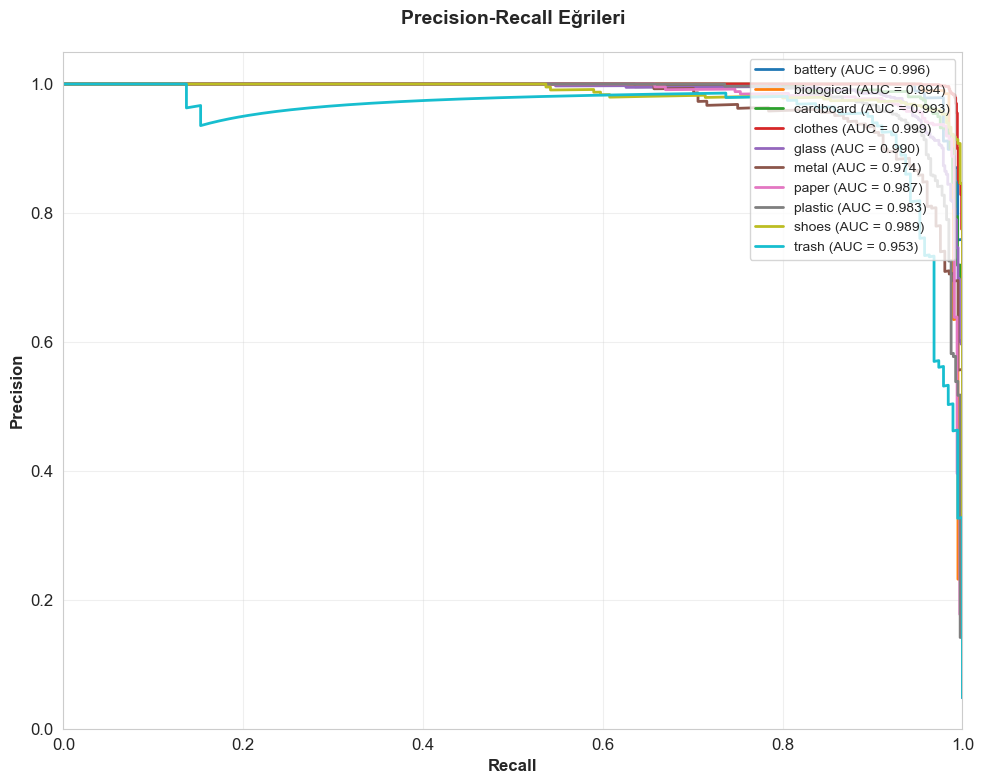

In [25]:

#Precision-Recall Eğrileri

print("\n📊 Precision-Recall Eğrileri:")

plt.figure(figsize=(10, 8))

for class_idx in range(num_classes):
    y_true_binary = (all_labels == class_idx).astype(int)
    y_score = all_probs[:, class_idx]
    
    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, lw=2, 
             label=f'{class_names[class_idx]} (AUC = {pr_auc:.3f})')

for class_idx in range(num_classes):
    support = np.sum(all_labels == class_idx)
    print(f"   {class_names[class_idx]:15}: Support = {support}, PR AUC = {pr_auc_scores[class_idx]:.3f}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12, fontweight="bold")
plt.ylabel('Precision', fontsize=12, fontweight="bold")
plt.title('Precision-Recall Eğrileri', fontsize=14, fontweight="bold", pad=20)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Her sınıf için Precision-Recall eğrileri çizdim. Dengesiz veri setlerinde daha bilgilendirici olan bu metriği kullanarak modelin her sınıf için kesinlik ve duyarlılık dengesini görselleştirdim


📊 En Sık Karıştırılan Sınıf Çiftleri:


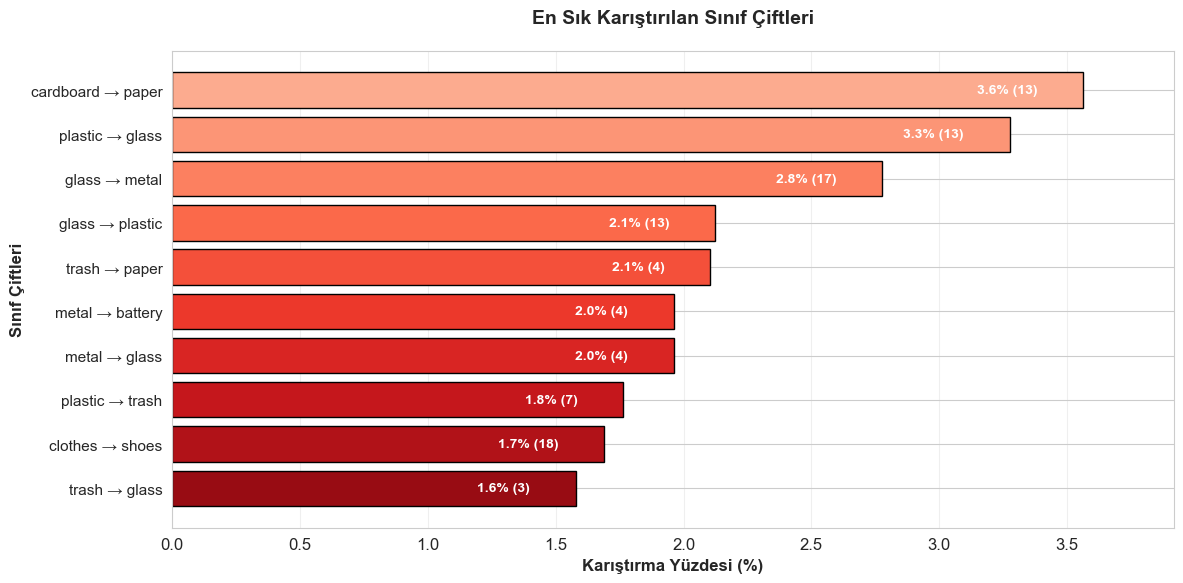


   Karıştırma Yüzdeleri:
   cardboard → paper        : 3.6% (13 örnek)
   plastic → glass          : 3.3% (13 örnek)
   glass → metal            : 2.8% (17 örnek)
   glass → plastic          : 2.1% (13 örnek)
   trash → paper            : 2.1% (4 örnek)
   metal → battery          : 2.0% (4 örnek)
   metal → glass            : 2.0% (4 örnek)
   plastic → trash          : 1.8% (7 örnek)
   clothes → shoes          : 1.7% (18 örnek)
   trash → glass            : 1.6% (3 örnek)


In [26]:

#En Sık Karıştırılan Sınıf Çiftleri

print("\n📊 En Sık Karıştırılan Sınıf Çiftleri:")

cm_raw = confusion_matrix(all_labels, all_preds)
confusion_pairs = []

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm_raw[i, j] > 0:
            percentage = cm_raw[i, j] / cm_raw[i].sum() * 100
            confusion_pairs.append({
                'class_pair': f'{class_names[i]} → {class_names[j]}',
                'count': cm_raw[i, j],
                'percentage': percentage
            })

confusion_pairs.sort(key=lambda x: x['percentage'], reverse=True)

top_confusion_pairs = confusion_pairs[:min(10, len(confusion_pairs))]

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(top_confusion_pairs))
percentages = [pair['percentage'] for pair in top_confusion_pairs]
class_pairs = [pair['class_pair'] for pair in top_confusion_pairs]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_confusion_pairs)))

bars = ax.barh(y_pos, percentages, color=colors, edgecolor="black", linewidth=1)
ax.set_xlabel('Karıştırma Yüzdesi (%)', fontsize=12, fontweight="bold")
ax.set_ylabel('Sınıf Çiftleri', fontsize=12, fontweight="bold")
ax.set_title('En Sık Karıştırılan Sınıf Çiftleri', fontsize=14, fontweight="bold", pad=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(class_pairs, fontsize=11)
ax.invert_yaxis()  # En yüksek değer üstte
ax.set_xlim(0, max(percentages) * 1.1)
ax.grid(True, alpha=0.3, axis='x')

for bar, percentage, count in zip(bars, percentages, [pair['count'] for pair in top_confusion_pairs]):
    width = bar.get_width()
    if width > max(percentages) * 0.1:  
        ax.text(width - max(percentages)*0.05, bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}% ({count})', 
                ha='right', va='center', color='white', fontsize=10, fontweight="bold")
    else:  
        ax.text(width + max(percentages)*0.01, bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}% ({count})', 
                ha='left', va='center', color='black', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n   Karıştırma Yüzdeleri:")
for pair in top_confusion_pairs:
    print(f"   {pair['class_pair']:25}: {pair['percentage']:.1f}% ({pair['count']} örnek)")



Modelin en çok hangi sınıf çiftlerini karıştırdığını analiz ettim. Karışıklık matrisinden yararlanarak bir sınıfın başka bir sınıf ile ne sıklıkta karıştırıldığını hesapladım.

In [27]:

print("PERFORMANS TABLOSU")

detailed_performance = []
for class_idx, class_name in enumerate(class_names):
    class_mask = (all_labels == class_idx)
    class_preds_filtered = all_preds[class_mask]
    class_labels_filtered = all_labels[class_mask]
    
    tp = np.sum((class_preds_filtered == class_idx) & (class_labels_filtered == class_idx))
    fp = np.sum((class_preds_filtered == class_idx) & (class_labels_filtered != class_idx))
    fn = np.sum((class_preds_filtered != class_idx) & (class_labels_filtered == class_idx))
    
    total = len(class_labels_filtered)
    
    accuracy_val = tp / total if total > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = 2 * precision_val * recall_val / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0
    
    if class_idx < cm_raw.shape[1]:
        confusions = [(j, cm_raw[class_idx, j]) for j in range(num_classes) if j != class_idx]
        if confusions:
            most_confused_idx, most_confused_count = max(confusions, key=lambda x: x[1])
            confusion_percentage = most_confused_count / cm_raw[class_idx].sum() * 100
            most_confused = f"{class_names[most_confused_idx]} ({confusion_percentage:.1f}%)"
        else:
            most_confused = "-"
    else:
        most_confused = "-"
    
    detailed_performance.append({
        "Sınıf": class_name,
        "Toplam": total,
        "Doğru": tp,
        "Accuracy": accuracy_val * 100,
        "Precision": precision_val * 100,
        "Recall": recall_val * 100,
        "F1-Score": f1_val * 100,
        "En Çok Karıştığı": most_confused
    })

summary_df = pd.DataFrame(detailed_performance)

styled_df = summary_df.style\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%', 
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })\
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                        cmap='YlGn', vmin=85, vmax=100)\
    .set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#2E86C1'), 
                  ('color', 'white'),
                  ('font-weight', 'bold'),
                  ('text-align', 'center'),
                  ('font-size', '12px'),
                  ('padding', '8px'),
                  ('border', '1px solid #ddd')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                  ('padding', '6px'),
                  ('border', '1px solid #ddd'),
                  ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:nth-child(odd)',
         'props': [('background-color', 'white')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#D6EAF8'),
                  ('cursor', 'pointer')]},
        {'selector': '',
         'props': [('border-collapse', 'collapse'),
                  ('width', '100%')]}
    ])\
    .set_caption(f'Toplam Test Örnekleri: {len(all_labels)} | Genel Accuracy: {accuracy*100:.2f}%')\
    .hide(axis='index')

try:
    from IPython.display import display
    display(styled_df)
except Exception as e:
    print(f"⚠️  Tablo gösterilemedi: {e}")
    print("\nAlternatif basit tablo:")
    print(summary_df.to_string(index=False, formatters={
        'Accuracy': '{:.2f}%'.format,
        'Precision': '{:.2f}%'.format,
        'Recall': '{:.2f}%'.format,
        'F1-Score': '{:.2f}%'.format
    }))




PERFORMANS TABLOSU


Sınıf,Toplam,Doğru,Accuracy,Precision,Recall,F1-Score,En Çok Karıştığı
battery,189,185,97.88%,100.00%,97.88%,98.93%,metal (1.1%)
biological,200,197,98.50%,100.00%,98.50%,99.24%,paper (1.0%)
cardboard,365,344,94.25%,100.00%,94.25%,97.04%,paper (3.6%)
clothes,1065,1042,97.84%,100.00%,97.84%,98.91%,shoes (1.7%)
glass,612,575,93.95%,100.00%,93.95%,96.88%,metal (2.8%)
metal,204,192,94.12%,100.00%,94.12%,96.97%,battery (2.0%)
paper,336,328,97.62%,100.00%,97.62%,98.80%,trash (1.2%)
plastic,397,367,92.44%,100.00%,92.44%,96.07%,glass (3.3%)
shoes,395,388,98.23%,100.00%,98.23%,99.11%,clothes (0.8%)
trash,190,176,92.63%,100.00%,92.63%,96.17%,paper (2.1%)


Detaylı performans tablosu oluşturdum. Her sınıf için doğruluk, kesinlik, duyarlılık ve F1 skoru hesapladım. Ayrıca her sınıfın en çok hangi sınıfla karıştığını ve yüzdesini gösterdim. 

In [28]:
# En iyi ve en kötü performans gösteren sınıflar
best_f1 = summary_df.loc[summary_df['F1-Score'].idxmax()]
worst_f1 = summary_df.loc[summary_df['F1-Score'].idxmin()]

best_acc = summary_df.loc[summary_df['Accuracy'].idxmax()]
worst_acc = summary_df.loc[summary_df['Accuracy'].idxmin()]

print(f"\n🏆 EN İYİ PERFORMANS:")
print(f"   • F1-Score: {best_f1['Sınıf']} ({best_f1['F1-Score']:.1f}%)")
print(f"   • Accuracy: {best_acc['Sınıf']} ({best_acc['Accuracy']:.1f}%)")

print(f"\n⚠️  EN DÜŞÜK PERFORMANS:")
print(f"   • F1-Score: {worst_f1['Sınıf']} ({worst_f1['F1-Score']:.1f}%)")
print(f"   • Accuracy: {worst_acc['Sınıf']} ({worst_acc['Accuracy']:.1f}%)")

print(f"\n📊 ORTALAMALAR:")
print(f"   • Ortalama F1-Score: {summary_df['F1-Score'].mean():.1f}%")
print(f"   • Ortalama Accuracy: {summary_df['Accuracy'].mean():.1f}%")
print(f"   • Ortalama Precision: {summary_df['Precision'].mean():.1f}%")
print(f"   • Ortalama Recall: {summary_df['Recall'].mean():.1f}%")

print(f"\n📈 STANDART SAPMALAR:")
print(f"   • F1-Score Std: {summary_df['F1-Score'].std():.1f}%")
print(f"   • Accuracy Std: {summary_df['Accuracy'].std():.1f}%")



🏆 EN İYİ PERFORMANS:
   • F1-Score: biological (99.2%)
   • Accuracy: biological (98.5%)

⚠️  EN DÜŞÜK PERFORMANS:
   • F1-Score: plastic (96.1%)
   • Accuracy: plastic (92.4%)

📊 ORTALAMALAR:
   • Ortalama F1-Score: 97.8%
   • Ortalama Accuracy: 95.7%
   • Ortalama Precision: 100.0%
   • Ortalama Recall: 95.7%

📈 STANDART SAPMALAR:
   • F1-Score Std: 1.3%
   • Accuracy Std: 2.5%


Model performansının özetini çıkardım. En iyi ve en kötü performans gösteren sınıfları belirledim. Ortalama değerler ve standart sapmalar ile modelin genel istikrarını ölçtüm. 

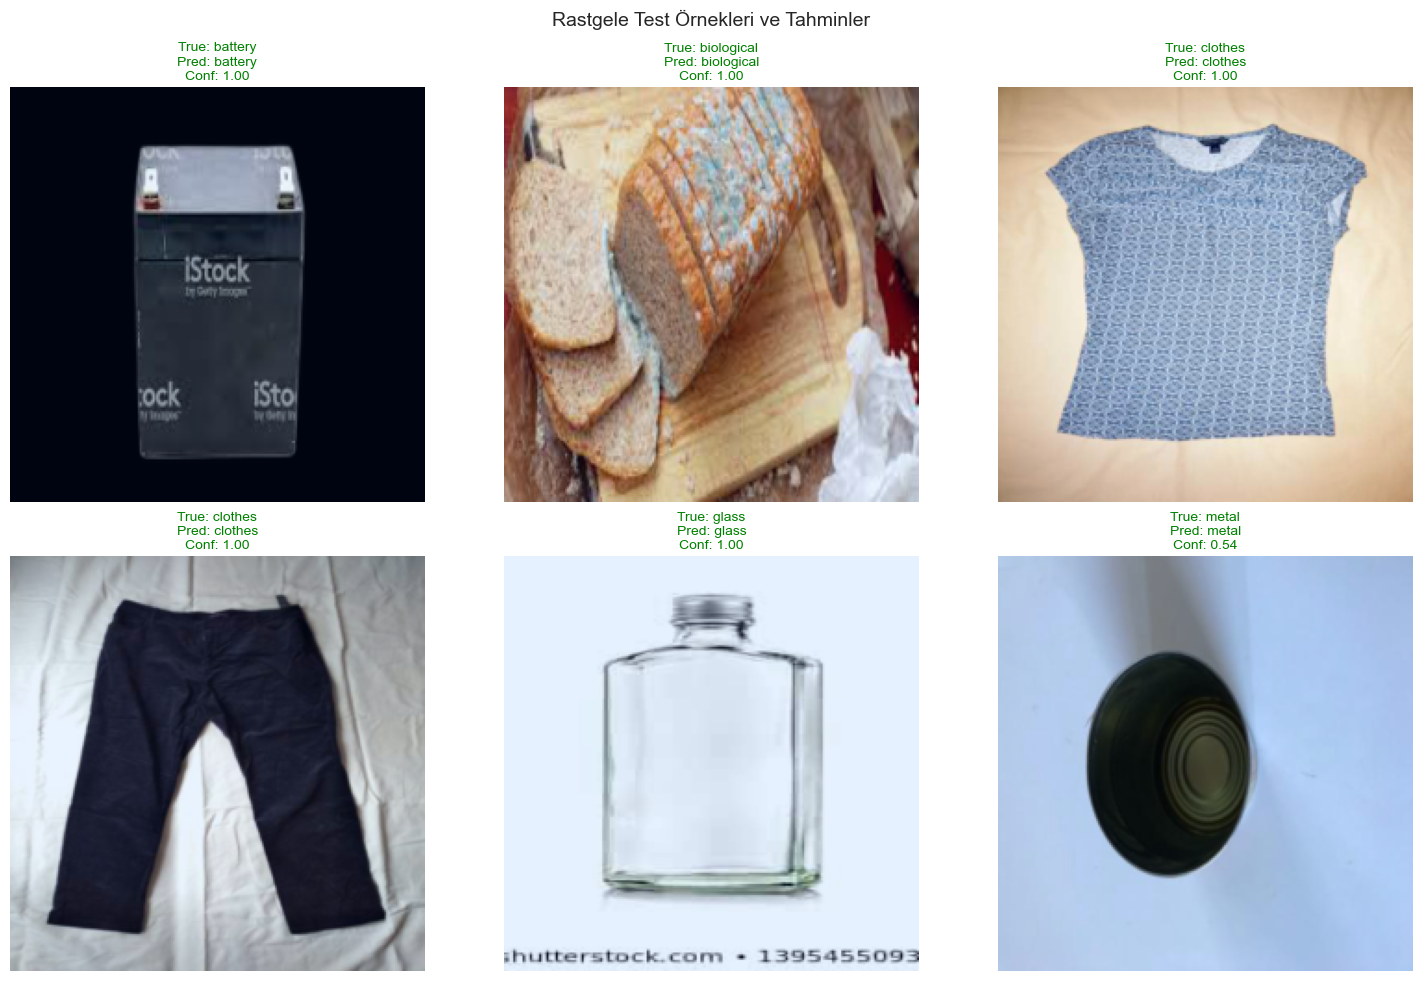

In [32]:

#ÖRNEK TAHMİNLER
def visualize_predictions(model, dataset, num_samples=6):
    """Rastgele örneklerle tahminleri göster"""
    indices = random.sample(range(len(dataset)), num_samples)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, ax in zip(indices, axes):
        sample = dataset[idx]
        image = sample["image"].unsqueeze(0).to(device)
        true_label = sample["label"]
        true_class = sample["class_name"]
        
        with torch.no_grad():
            outputs = model(image)
            probs = torch.softmax(outputs, dim=1)
            pred_prob, pred_label = torch.max(probs, dim=1)
        
        img = sample["image"].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        ax.imshow(img)
        ax.axis('off')
        
        pred_class = idx_to_class[pred_label.item()]
        is_correct = pred_label.item() == true_label
        
        color = 'green' if is_correct else 'red'
        ax.set_title(
            f"True: {true_class}\nPred: {pred_class}\nConf: {pred_prob.item():.2f}",
            color=color,
            fontsize=10
        )
    
    plt.suptitle("Rastgele Test Örnekleri ve Tahminler", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, num_samples=6)


Rastgele test örneklerini görselleştirdim.Doğru tahminleri yeşil, yanlış tahminleri kırmızı renkle işaretledim. Böylece modelin gerçek dünyada nasıl performans gösterdiğini somut örneklerle göstermiş oldum.